# Урок 1.1. Обучение с учителем: данные, модель, ошибка

**Интерактивная версия:** `lessons/lesson_1_1/web/index.html`

После урока вы сможете:
- читать таблицу данных и обозначения $x_i$, $x_{ij}$, $y_i$, $X$, $y$; кодировать категории;
- объяснить модель данных $y = f(x) + \varepsilon$, почему шум — нижняя граница ошибки и почему он зависит от признаков;
- обучить линейную модель с несколькими признаками и прочитать её веса;
- вручную посчитать остатки, MSE, RMSE, MAE и $R^2$;
- составить матрицу ошибок классификатора и посчитать долю верных, полноту и точность;
- объяснить обучение как поиск минимума ошибки по параметрам;
- отличать обобщение от запоминания, интерполяцию от экстраполяции;
- честно оценить модель на тестовой выборке и пройти весь рабочий процесс проекта.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gbcourse import GBRegressor, RegressionTree, datasets, style
from gbcourse.metrics import mse
from gbcourse.rng import Mulberry32
from gbcourse.plotting import plot_data, plot_residuals, plot_truth, use_course_style

use_course_style()

## 1. Данные: объекты, признаки, ответы

Шесть квартир из урока 1, но теперь с четырьмя признаками. Строка — объект $x_i$, столбец — признак,
последний столбец — ответ $y$.

In [2]:
flats = pd.DataFrame({
    "area": [30, 40, 50, 60, 70, 80],  # площадь, м²
    "floor": [5, 9, 1, 3, 12, 7],
    "district": ["Север", "Центр", "Юг", "Центр", "Север", "Центр"],
    "metro": [15, 5, 20, 10, 8, 6],  # до метро, мин
    "price": [3, 5, 4, 8, 9, 13],  # цена, млн — целевая переменная
})
X_flats = flats.drop(columns="price")  # матрица признаков n × d
y_flats = flats["price"]  # вектор ответов
print("X:", X_flats.shape, " y:", y_flats.shape)
print("объект x_3:", X_flats.iloc[2].astype(str).tolist(), "→ y_3 =", y_flats.iloc[2])
print("x_32 (этаж объекта 3) =", X_flats.iloc[2, 1])
flats

X: (6, 4)  y: (6,)
объект x_3: ['50', '1', 'Юг', '20'] → y_3 = 4
x_32 (этаж объекта 3) = 1


,area,floor,district,metro,price
0,30,5,Север,15,3
1,40,9,Центр,5,5
2,50,1,Юг,20,4
3,60,3,Центр,10,8
4,70,12,Север,8,9
5,80,7,Центр,6,13


Категориальный признак «район» перед обучением нужно превратить в числа. Самый простой способ —
отдельный столбец 0/1 на каждую категорию (one-hot); подробно — урок 10.1.

In [3]:
pd.get_dummies(X_flats, columns=["district"], dtype=int)

,area,floor,metro,district_Север,district_Центр,district_Юг
0,30,5,15,1,0,0
1,40,9,5,0,1,0
2,50,1,20,0,0,1
3,60,3,10,0,1,0
4,70,12,8,1,0,0
5,80,7,6,0,1,0


## 2. Откуда берутся данные: $y = f(x) + \varepsilon$

Учебный набор «волна с трендом»: $f(x) = \sin x + 0.3x$, шум $\sigma = 0.4$. Даже идеальная модель $F = f$
ошибается на этих точках в среднем примерно на $\sigma^2 = 0.16$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


средний квадрат шума на 40 точках: 0.1821   σ² = 0.1600


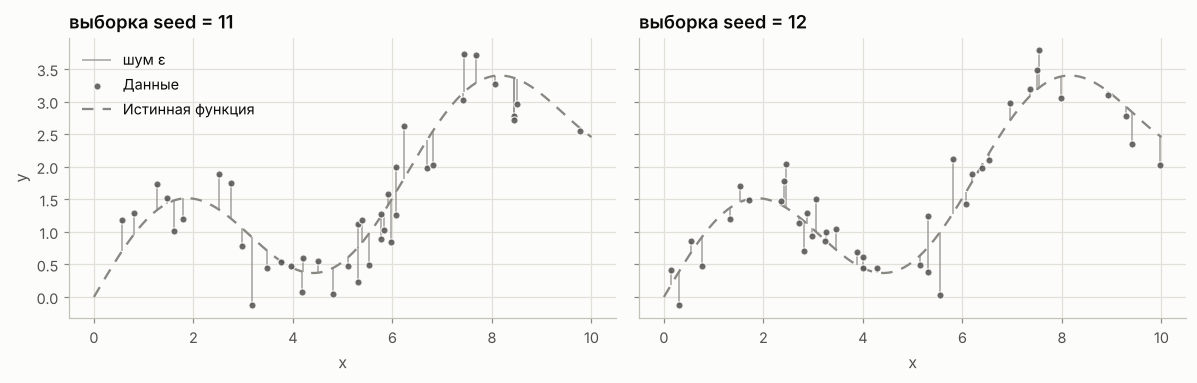

средний квадрат шума при n = 10, 100, 1000, 10000: [0.0811 0.1407 0.1605 0.1603]


In [4]:
X, y = datasets.regression_1d(kind="wave", n=40, noise=0.4, seed=11)
f = datasets.true_function("wave", X[:, 0])
print(f"средний квадрат шума на 40 точках: {np.mean((y - f) ** 2):.4f}   σ² = {0.4 ** 2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, seed in zip(axes, (11, 12)):
    Xs, ys = datasets.regression_1d(kind="wave", n=40, noise=0.4, seed=seed)
    plot_residuals(ax, Xs, ys, datasets.true_function("wave", Xs[:, 0]), label="шум ε")
    plot_data(ax, Xs, ys)
    plot_truth(ax, "wave")
    ax.set(title=f"выборка seed = {seed}", xlabel="x")
axes[0].set_ylabel("y")
axes[0].legend()
fig.tight_layout()
plt.show()

big = [np.mean((ys - datasets.true_function("wave", Xs[:, 0])) ** 2)
       for Xs, ys in [datasets.regression_1d(kind="wave", n=n, noise=0.4, seed=1) for n in (10, 100, 1000, 10000)]]
print("средний квадрат шума при n = 10, 100, 1000, 10000:", np.round(big, 4))

## 3. Что считать шумом — зависит от признаков

60 квартир: цена $= 0.12 \cdot \text{площадь} + 3 - 0.15 \cdot \text{метро} + \varepsilon$, $\sigma = 0.5$.
Модель, которая не знает время до метро, видит его влияние как шум: её остатки зависят от метро.

только площадь  : MSE = 1.574   (σ² = 0.25)
площадь и метро : MSE = 0.271   (σ² = 0.25)


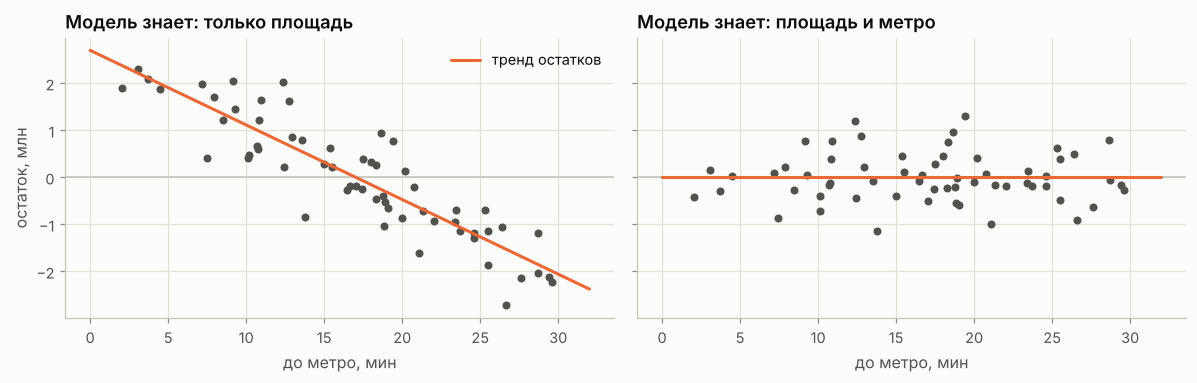

In [5]:
rng = Mulberry32(3)
rows = []
for _ in range(60):
    area = rng.uniform(30, 100)  # порядок вызовов ГПСЧ: площадь → метро → шум (как в виджете)
    metro = rng.uniform(2, 30)
    eps = rng.normal()
    rows.append((area, metro, 0.12 * area + 3 - 0.15 * metro + 0.5 * eps))
h_area, h_metro, h_y = np.array(rows).T


def lstsq_fit(cols, y):
    """Наименьшие квадраты: веса признаков, сдвиг и остатки."""
    A = np.column_stack(cols + [np.ones_like(y)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coef, y - A @ coef


fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, cols, title in ((axes[0], [h_area], "только площадь"), (axes[1], [h_area, h_metro], "площадь и метро")):
    coef, r = lstsq_fit(cols, h_y)
    print(f"{title:16s}: MSE = {np.mean(r ** 2):.3f}   (σ² = 0.25)")
    ax.axhline(0, color=style.AXIS, lw=1)
    ax.scatter(h_metro, r, color=style.ROLE["data"], s=18)
    b = np.polyfit(h_metro, r, 1)
    ax.plot([0, 32], np.polyval(b, [0, 32]), color=style.ORANGE, lw=2, label="тренд остатков")
    ax.set(xlabel="до метро, мин", title=f"Модель знает: {title}")
axes[0].set_ylabel("остаток, млн")
axes[0].legend()
fig.tight_layout()
plt.show()

## 4. Модель с несколькими признаками

Линейная модель $F = \theta_1 \cdot \text{площадь} + \theta_2 \cdot \text{метро} + \theta_0$ на шести квартирах.

In [6]:
x6 = flats["area"].to_numpy(float)
y6 = flats["price"].to_numpy(float)
m6 = flats["metro"].to_numpy(float)
theta, r_two = lstsq_fit([x6, m6], y6)
_, r_one = lstsq_fit([x6], y6)
print(f"веса: площадь {theta[0]:.4f}, метро {theta[1]:.4f}, сдвиг {theta[2]:.4f}")
print(f"SSE: только площадь {np.sum(r_one ** 2):.3f}, площадь и метро {np.sum(r_two ** 2):.3f}")
print(f"квартира №3: прогноз {theta @ [50, 20, 1]:.2f} при цене 4")
print(f"новая квартира 65 м², 7 мин: {theta @ [65, 7, 1]:.2f} млн")

веса: площадь 0.1650, метро -0.1796, сдвиг -0.1568
SSE: только площадь 7.771, площадь и метро 3.347
квартира №3: прогноз 4.50 при цене 4
новая квартира 65 м², 7 мин: 9.31 млн


## 5. Ошибка руками: правило риелтора $F(x) = 0.2x - 4$

In [7]:
F6 = 0.2 * x6 - 4
r6 = y6 - F6
table = pd.DataFrame({"x": x6, "y": y6, "F(x)": F6, "r": r6, "|r|": np.abs(r6), "r²": r6**2})
print(table.to_string(index=False))
sse, sse0 = np.sum(r6**2), np.sum((y6 - y6.mean()) ** 2)
print(f"\nсумма остатков = {r6.sum():.1f} (ошибки взаимно гасятся!)")
print(f"MSE = {sse / 6:.4f}  RMSE = {np.sqrt(sse / 6):.4f} млн  MAE = {np.mean(np.abs(r6)):.4f} млн")
print(f"R² = 1 − {sse:.0f}/{sse0:.0f} = {1 - sse / sse0:.4f}")
a, b = np.polyfit(x6, y6, 1)
print(f"лучшая прямая: a = {a:.4f}, b = {b:.4f}, SSE = {np.sum((y6 - a * x6 - b) ** 2):.4f}")

   x    y  F(x)    r  |r|  r²
30.0  3.0   2.0  1.0  1.0 1.0
40.0  5.0   4.0  1.0  1.0 1.0
50.0  4.0   6.0 -2.0  2.0 4.0
60.0  8.0   8.0  0.0  0.0 0.0
70.0  9.0  10.0 -1.0  1.0 1.0
80.0 13.0  12.0  1.0  1.0 1.0

сумма остатков = 0.0 (ошибки взаимно гасятся!)
MSE = 1.3333  RMSE = 1.1547 млн  MAE = 1.0000 млн
R² = 1 − 8/70 = 0.8857
лучшая прямая: a = 0.1886, b = -3.3714, SSE = 7.7714


Выброс (квартира №6 «стоит» 30 млн) по-разному влияет на метрики: квадрат раздувает большие ошибки.

In [8]:
y_out = y6.copy()
y_out[5] = 30
r_out = y_out - F6
print(f"с выбросом: MSE = {np.mean(r_out**2):.2f}, RMSE = {np.sqrt(np.mean(r_out**2)):.2f}, MAE = {np.mean(np.abs(r_out)):.2f}")

с выбросом: MSE = 55.17, RMSE = 7.43, MAE = 3.83


## 6. Ошибка классификатора: матрица ошибок

12 заёмщиков: признак — доля дохода на платежи, ответ — 1, если кредит не вернули. Правило «x ≥ t → 1».

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

xc = np.array([12, 18, 25, 30, 34, 41, 47, 52, 58, 63, 71, 80])
yc = np.array([0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1])
for t in (32, 50, 66):
    pc = (xc >= t).astype(int)
    print(f"t = {t}: [[TN, FP], [FN, TP]] = {confusion_matrix(yc, pc).tolist()}, доля верных {accuracy_score(yc, pc):.3f}, "
          f"полнота {recall_score(yc, pc):.2f}, точность {precision_score(yc, pc):.2f}")
print(f"базовая «все вернут»: {np.mean(yc == 0):.3f}")

# редкий класс: 48 обычных операций и 2 мошеннические
rng = Mulberry32(4)
xf = np.array([int(rng.uniform(5, 75)) for _ in range(48)] + [61.5, 86.5])
yf = np.array([0] * 48 + [1, 1])
for t in (101, 80, 60):
    pf = (xf >= t).astype(int)
    print(f"операции, t = {t:3d}: доля верных {accuracy_score(yf, pf):.2f}, полнота {recall_score(yf, pf, zero_division=0):.2f}")

t = 32: [[TN, FP], [FN, TP]] = [[4, 3], [0, 5]], доля верных 0.750, полнота 1.00, точность 0.62
t = 50: [[TN, FP], [FN, TP]] = [[6, 1], [1, 4]], доля верных 0.833, полнота 0.80, точность 0.80
t = 66: [[TN, FP], [FN, TP]] = [[7, 0], [3, 2]], доля верных 0.750, полнота 0.40, точность 1.00
базовая «все вернут»: 0.583
операции, t = 101: доля верных 0.96, полнота 0.00
операции, t =  80: доля верных 0.98, полнота 0.50
операции, t =  60: доля верных 0.80, полнота 1.00


## 7. Обучение = поиск дна рельефа ошибки

Для 40 точек «волны» нарисуем MSE как функцию параметров константы и прямой и найдём минимумы.

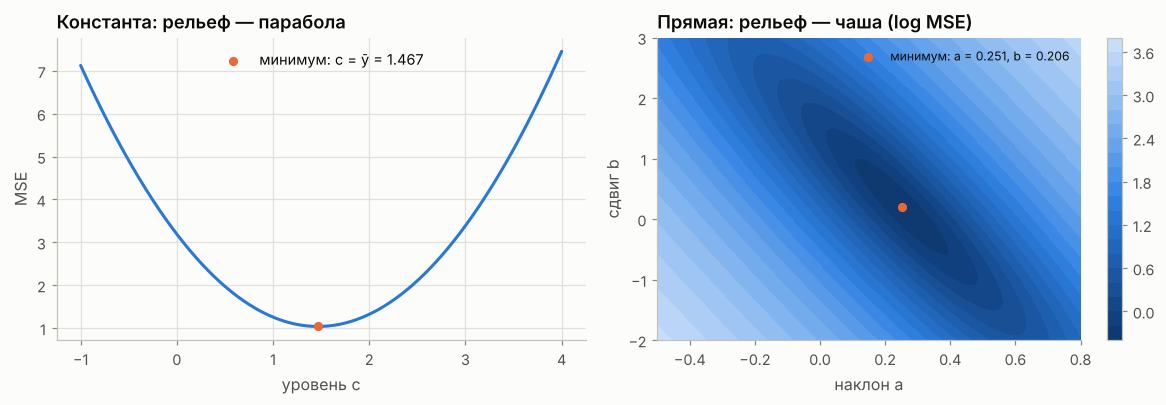

константа: MSE = 1.0384
прямая:    MSE = 0.7056
ступенька: порог = 6.156, MSE = 0.3115


In [10]:
cs = np.linspace(-1, 4, 501)
mse_c = [np.mean((y - c) ** 2) for c in cs]
A, B = np.meshgrid(np.linspace(-0.5, 0.8, 140), np.linspace(-2, 3, 140))
mse_ab = np.mean((y[None, None, :] - (A[..., None] * X[:, 0] + B[..., None])) ** 2, axis=-1)
a_opt, b_opt = np.polyfit(X[:, 0], y, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(cs, mse_c, color=style.BLUE)
axes[0].scatter([y.mean()], [np.mean((y - y.mean()) ** 2)], color=style.ORANGE, zorder=3, label=f"минимум: c = ȳ = {y.mean():.3f}")
axes[0].set(xlabel="уровень c", ylabel="MSE", title="Константа: рельеф — парабола")
axes[0].legend()
cf = axes[1].contourf(A, B, np.log(mse_ab), levels=20, cmap=style.cmap_sequential().reversed())
axes[1].scatter([a_opt], [b_opt], color=style.ORANGE, zorder=3, label=f"минимум: a = {a_opt:.3f}, b = {b_opt:.3f}")
axes[1].set(xlabel="наклон a", ylabel="сдвиг b", title="Прямая: рельеф — чаша (log MSE)")
axes[1].legend(loc="upper right", fontsize=8)
fig.colorbar(cf, ax=axes[1])
fig.tight_layout()
plt.show()

stump = RegressionTree(max_depth=1).fit(X, -y)
print(f"константа: MSE = {np.mean((y - y.mean()) ** 2):.4f}")
print(f"прямая:    MSE = {np.mean((y - a_opt * X[:, 0] - b_opt) ** 2):.4f}")
print(f"ступенька: порог = {stump.nodes[0].threshold:.3f}, MSE = {mse(y, stump.predict(X)):.4f}")

Чем гибче модель, тем ниже её лучшая MSE на обучении. Но это ещё не значит, что она лучше на новых данных.

## 8. Обобщение: «зубрила», интерполяция и экстраполяция

Модели обучены на 40 точках с $x$ от 0 до 10; проверяем на 70 новых точках с $x$ от 0 до 14.

«зубрила»        обучение 0.000   новые x≤10: 0.324   x>10: 2.143
прямая           обучение 0.706   новые x≤10: 0.572   x>10: 1.114
дерево глубины 3 обучение 0.090   новые x≤10: 0.281   x>10: 1.966
бустинг          обучение 0.027   новые x≤10: 0.255   x>10: 2.064


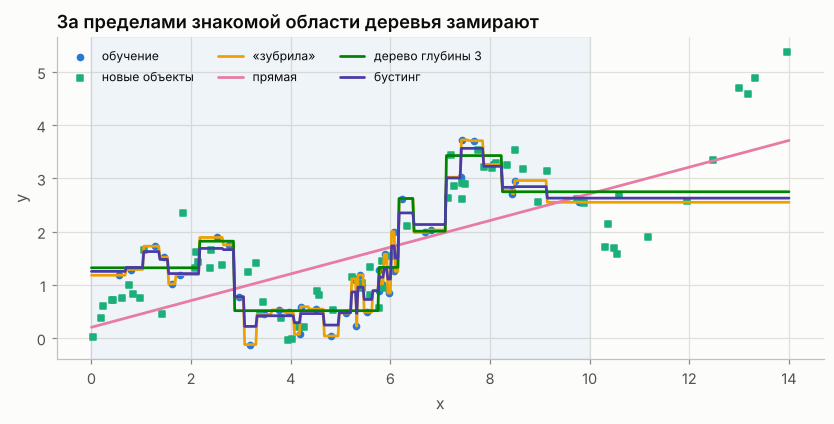

In [11]:
Xn, yn = datasets.regression_1d(kind="wave", n=70, noise=0.4, seed=12, x_min=0, x_max=14)
inside = Xn[:, 0] <= 10
gen_models = {
    "«зубрила»": lambda Z: y[np.abs(Z[:, :1] - X[:, 0]).argmin(axis=1)],
    "прямая": lambda Z: a_opt * Z[:, 0] + b_opt,
    "дерево глубины 3": RegressionTree(max_depth=3).fit(X, -y).predict,
    "бустинг": GBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2).fit(X, y).predict,
}
gz = np.linspace(0, 14, 561)[:, None]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axvspan(0, 10, color=style.BLUE, alpha=0.06)
ax.scatter(X[:, 0], y, color=style.ROLE["train"], s=16, label="обучение")
ax.scatter(Xn[:, 0], yn, color=style.ROLE["test"], marker="s", s=14, label="новые объекты")
for (name, predict), color in zip(gen_models.items(), style.SERIES[3:7]):
    print(f"{name:16s} обучение {mse(y, predict(X)):.3f}   новые x≤10: {mse(yn[inside], predict(Xn[inside])):.3f}"
          f"   x>10: {mse(yn[~inside], predict(Xn[~inside])):.3f}")
    ax.plot(gz[:, 0], predict(gz), color=color, lw=1.8, label=name)
ax.set(xlabel="x", ylabel="y", title="За пределами знакомой области деревья замирают")
ax.legend(fontsize=8, ncol=3)
plt.show()

## 9. Обучение и тест: честная оценка

50 точек делим на обучение (35) и тест (15) 30 разными способами. Ошибка на тесте у дерева глубины 3
сильно зависит от разбиения.

разбиение 0: обучение 0.1196, тест 0.3209
тест по 30 разбиениям: от 0.125 до 0.521, среднее 0.301
обучение в среднем: 0.114  (оптимистично)


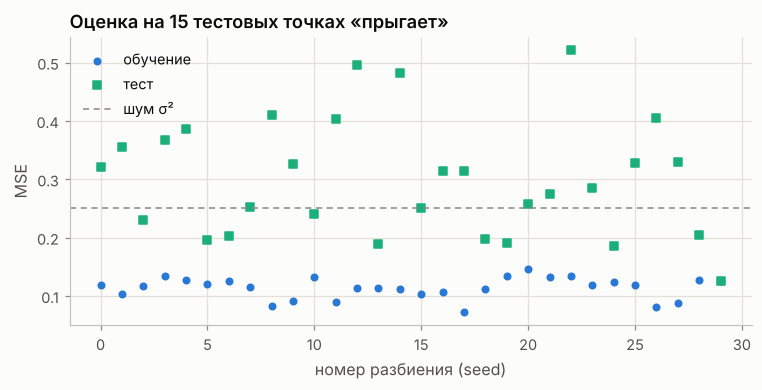

In [12]:
Xw, yw = datasets.regression_1d(kind="wave", n=50, noise=0.5, seed=21)
rows = []
for seed in range(30):
    Xtr, Xte, ytr, yte = datasets.train_test_split(Xw, yw, test_size=0.3, seed=seed)
    tree = RegressionTree(max_depth=3).fit(Xtr, -ytr)
    rows.append((mse(ytr, tree.predict(Xtr)), mse(yte, tree.predict(Xte))))
rows = np.array(rows)
print(f"разбиение 0: обучение {rows[0, 0]:.4f}, тест {rows[0, 1]:.4f}")
print(f"тест по 30 разбиениям: от {rows[:, 1].min():.3f} до {rows[:, 1].max():.3f}, среднее {rows[:, 1].mean():.3f}")
print(f"обучение в среднем: {rows[:, 0].mean():.3f}  (оптимистично)")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.scatter(range(30), rows[:, 0], color=style.ROLE["train"], s=18, label="обучение")
ax.scatter(range(30), rows[:, 1], color=style.ROLE["test"], marker="s", s=22, label="тест")
ax.axhline(0.25, color=style.MUTED, ls=(0, (4, 3)), lw=1, label="шум σ²")
ax.set(xlabel="номер разбиения (seed)", ylabel="MSE", title="Оценка на 15 тестовых точках «прыгает»")
ax.legend()
plt.show()

## 10. Глубина дерева: обучение против теста

На 200 точках сравним деревья глубины 0…12. Ошибка на обучении падает всегда, на тесте — до поры.

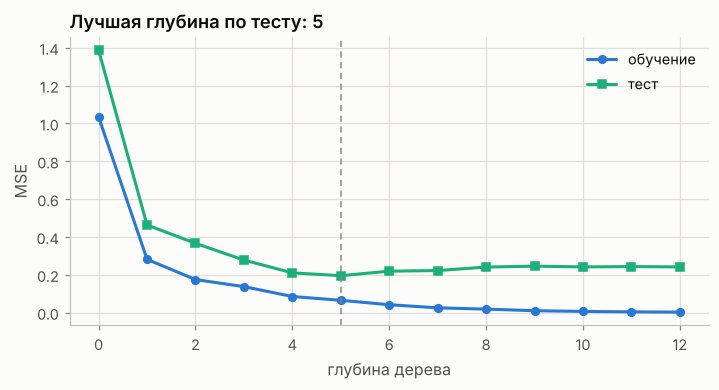

In [13]:
X2, y2 = datasets.regression_1d(kind="wave", n=200, noise=0.4, seed=11)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X2, y2, test_size=0.3, seed=0)
depths = range(0, 13)
tr_err, te_err = [], []
for d in depths:
    if d == 0:
        p_tr, p_te = np.full_like(y_tr, y_tr.mean()), np.full_like(y_te, y_tr.mean())
    else:
        t = RegressionTree(max_depth=d).fit(X_tr, -y_tr)
        p_tr, p_te = t.predict(X_tr), t.predict(X_te)
    tr_err.append(mse(y_tr, p_tr))
    te_err.append(mse(y_te, p_te))
best = int(np.argmin(te_err))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(depths, tr_err, marker="o", color=style.ROLE["train"], label="обучение")
ax.plot(depths, te_err, marker="s", color=style.ROLE["test"], label="тест")
ax.axvline(best, color=style.MUTED, ls=(0, (4, 3)), lw=1)
ax.set(xlabel="глубина дерева", ylabel="MSE", title=f"Лучшая глубина по тесту: {best}")
ax.legend()
plt.show()

## 11. Сверка с scikit-learn: единый интерфейс fit / predict

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

print("метрики правила риелтора (sklearn):", mean_squared_error(y6, F6), mean_absolute_error(y6, F6), r2_score(y6, F6))
for name, model in {
    "среднее (базовая)": DummyRegressor(),
    "прямая": LinearRegression(),
    "дерево глубины 3": DecisionTreeRegressor(max_depth=3),
    "бустинг": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
}.items():
    model.fit(X_tr, y_tr)
    print(f"{name:18s} тест MSE = {mse(y_te, model.predict(X_te)):.3f}")
ours = GBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2).fit(X_tr, y_tr)
print(f"{'gbcourse бустинг':18s} тест MSE = {mse(y_te, ours.predict(X_te)):.3f}")

метрики правила риелтора (sklearn): 1.3333333333333333 1.0 0.8857142857142857
среднее (базовая)  тест MSE = 1.386
прямая             тест MSE = 0.825
дерево глубины 3   тест MSE = 0.278
бустинг            тест MSE = 0.202
gbcourse бустинг   тест MSE = 0.202


## 12. Весь проект целиком

800 объектов, 10 признаков (пять из них бесполезны). Тест откладываем первым, число деревьев выбираем
по валидации, тест используем один раз.

обучение / валидация / тест: 450 150 200
среднее (базовая)  валидация MSE = 26.39
линейная модель    валидация MSE = 6.11
дерево глубины 5   валидация MSE = 7.90


бустинг: лучшее число деревьев 876, валидация MSE = 2.41


ТЕСТ: бустинг MSE = 2.70, базовая MSE = 25.85


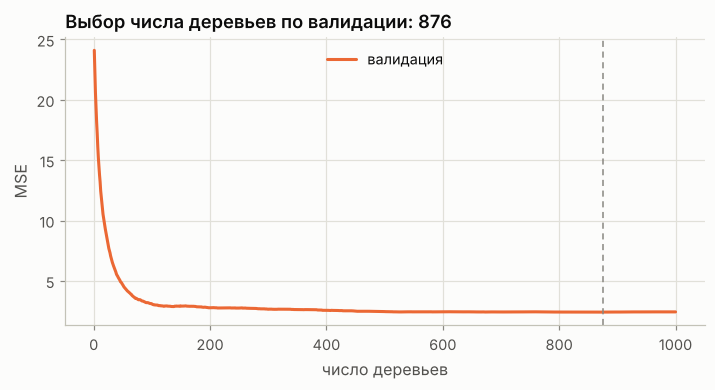

In [15]:
Xf, yf = datasets.friedman1(n=800, noise=1.0, seed=0)
X_rest, X_test, y_rest, y_test = datasets.train_test_split(Xf, yf, test_size=0.25, seed=0)
X_fit, X_val, y_fit, y_val = datasets.train_test_split(X_rest, y_rest, test_size=0.25, seed=1)
print("обучение / валидация / тест:", len(y_fit), len(y_val), len(y_test))
for name, model in {
    "среднее (базовая)": DummyRegressor(),
    "линейная модель": LinearRegression(),
    "дерево глубины 5": DecisionTreeRegressor(max_depth=5, random_state=0),
}.items():
    model.fit(X_fit, y_fit)
    print(f"{name:18s} валидация MSE = {mean_squared_error(y_val, model.predict(X_val)):.2f}")
gb = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1, max_depth=2, random_state=0).fit(X_fit, y_fit)
val_curve = [mean_squared_error(y_val, p) for p in gb.staged_predict(X_val)]
best_m = int(np.argmin(val_curve)) + 1
print(f"бустинг: лучшее число деревьев {best_m}, валидация MSE = {min(val_curve):.2f}")
final = GradientBoostingRegressor(n_estimators=best_m, learning_rate=0.1, max_depth=2, random_state=0).fit(X_rest, y_rest)
print(f"ТЕСТ: бустинг MSE = {mean_squared_error(y_test, final.predict(X_test)):.2f}, "
      f"базовая MSE = {mean_squared_error(y_test, np.full_like(y_test, y_rest.mean())):.2f}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(range(1, len(val_curve) + 1), val_curve, color=style.ROLE["valid"], label="валидация")
ax.axvline(best_m, color=style.MUTED, ls=(0, (4, 3)), lw=1)
ax.set(xlabel="число деревьев", ylabel="MSE", title=f"Выбор числа деревьев по валидации: {best_m}")
ax.legend()
plt.show()

## Упражнения

1. Найдите $x_{43}$ в таблице квартир. Существует ли $x_{25}$?
2. Посчитайте MSE, RMSE, MAE и $R^2$ константы «все квартиры по 7 млн».
3. Посчитайте $R^2$ правила $F(x) = 0.3x - 4$ и объясните знак.
4. Переберите константу на сетке и убедитесь, что минимум MSE — среднее.
5. Повторите сравнение глубин из раздела 10 для `noise=0.1` и `noise=1.0`. Как шум влияет на лучшую глубину?
6. Повторите эксперимент раздела 9 с долей теста 10 % и 50 %. Как меняется разброс оценки?
7. В разделе 6 найдите порог с наибольшей долей верных. Чем он лучше базовой модели?
8. В разделе 3 поставьте влияние метро 0 и 0.3. Как меняется разница между моделями?
9. В разделе 8 перебирайте глубину дерева 1…8. Почему ошибка при $x > 10$ почти не меняется?

<details><summary>Решения</summary>

`python lessons/lesson_1_1/exercises/solutions.py`
</details>